# Modelos de Clasificación para el Análisis del Estatus Ocupacional en México: Random Forest, AdaBoost, SVM y Redes Neuronales

## Introducción

El presente estudio analiza el estatus ocupacional de trabajadores en México,
distinguiendo entre empleadores y empleados subordinados a partir de datos de
la Encuesta Nacional de Ocupación y Empleo (ENOE) [2]. Con un universo de
91,242 registros y cuatro variables socioeconómicas —edad, género, escolaridad
e ingreso—, se evalúa la capacidad predictiva de cuatro algoritmos de
clasificación: Random Forest, AdaBoost, Máquina de Soporte Vectorial (SVM) con
kernel RBF y una Red Neuronal densa.

El problema presenta un reto técnico inherente: el fuerte desbalance de clases,
donde los empleadores representan apenas el 6.97% de la muestra. Este contexto
exige un diseño metodológico cuidadoso en la selección de métricas y en el
tratamiento de la clase minoritaria, aspectos que se abordan a lo largo del
reporte.

El objetivo central no es encontrar el modelo perfecto, sino comparar estrategias
de aprendizaje fundamentalmente distintas —Bagging, Boosting, margen máximo y
redes neuronales— evaluando su desempeño, interpretabilidad y viabilidad
computacional ante un problema real de clasificación con datos del mercado
laboral mexicano [2, 3, 4].

---

## Objetivo

Comparar el desempeño de cuatro algoritmos avanzados de clasificación —**Random Forest**, **AdaBoost**, **SVM con kernel RBF** y una **Red Neuronal densa (MLP)**— sobre el mismo conjunto de datos, evaluando su comportamiento ante el fuerte desbalance de clases y reflexionando sobre la relación entre complejidad, interpretabilidad y capacidad predictiva.

## Estructura del reporte

| Fase | Contenido |
|------|-----------|
| **Fase 1** | Configuración del experimento: validación del dataset, análisis exploratorio y partición estratificada |
| **Fase 2** | Construcción y entrenamiento de los cuatro modelos |
| **Fase 3** | Evaluación comparativa con métricas, matrices de confusión y curvas ROC |
| **Fase 4** | Análisis crítico y conclusiones |

---
## Fase 1 – Configuración del Experimento

### 1.1 Contexto y Diccionario de Variables

El conjunto de datos proviene de la **Encuesta Nacional de Ocupación y Empleo (ENOE)** del INEGI. El objetivo de clasificación es distinguir si una persona es **empleador** (dueño de negocio con trabajadores a cargo) o **empleado subordinado**, a partir de cuatro características socioeconómicas.

| Variable | Tipo | Rango | Descripción |
|---|---|---|---|
| `eda` | Numérica discreta | 18 – 98 | Edad del trabajador en años |
| `es_mujer` | Binaria (0/1) | {0, 1} | 1 = Mujer, 0 = Hombre |
| `anios_esc` | Numérica discreta | 0 – 24 | Años de escolaridad formal completada |
| `log_ingocup` | Numérica continua | 6.2 – 12.3 | Logaritmo natural del ingreso mensual ocupacional |
| `es_empleador` | **Binaria – Objetivo** | {0, 1} | **1 = Empleador, 0 = Empleado** |

> **¿Por qué logaritmo del ingreso?** Los ingresos en México siguen una distribución muy sesgada a la derecha (unas pocas personas ganan cantidades muy altas). Al aplicar el logaritmo natural se comprime esa escala: una diferencia multiplicativa de ×2 en cualquier nivel de ingreso genera el mismo desplazamiento en la escala logarítmica, haciendo los datos más homogéneos y favoreciendo la convergencia de los algoritmos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_sample_weight
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

### 1.2 Validación del Dataset

In [2]:
df = pd.read_csv('ENOE_SDEMT325_simplificado.csv')

print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
print(f'Dimensiones: {df.shape[0]:,} registros y {df.shape[1]} variables.')
print('-'*60)
print('Valores nulos por variable:')
print(df.isnull().sum())
print('-'*60)
print('Tipos de datos:')
print(df.dtypes)
print('-'*60)
print('Estadísticas descriptivas:')
display(df.describe().round(3))

INFORMACIÓN GENERAL DEL DATASET
Dimensiones: 91,242 registros y 5 variables.
------------------------------------------------------------
Valores nulos por variable:
eda             0
es_mujer        0
anios_esc       0
log_ingocup     0
es_empleador    0
dtype: int64
------------------------------------------------------------
Tipos de datos:
eda             float64
es_mujer          int64
anios_esc         int64
log_ingocup     float64
es_empleador      int64
dtype: object
------------------------------------------------------------
Estadísticas descriptivas:


,eda,es_mujer,anios_esc,log_ingocup,es_empleador
count,91242.000,91242.000,91242.000,91242.000,91242.000
mean,39.175,0.414,10.984,9.161,0.070
std,13.246,0.493,4.103,0.643,0.255
min,18.000,0.000,0.000,6.217,0.000
25%,28.000,0.000,9.000,8.854,0.000
50%,38.000,0.000,11.000,9.199,0.000
75%,49.000,1.000,14.000,9.518,0.000
max,98.000,1.000,24.000,12.278,1.000


#### Conclusión de la validación estructural

El dataset presenta condiciones óptimas para el modelado:

- **Sin valores faltantes**: las cinco variables están completas en los 91,242 registros, lo que confirma que el proceso de limpieza previo fue exitoso.
- **Tipos de datos coherentes**: `log_ingocup` son flotantes continuos; `es_mujer`, `anios_esc`, `eda`  y `es_empleador` son enteros discretos o binarios, en línea con el diccionario.
- **Volumen adecuado**: 91,242 observaciones constituyen una base estadística sólida para entrenar modelos de alta complejidad como SVM o redes neuronales.

> **Nota**: Aunque computacionalmente `eda` sea de tipo flotante continuo, estadísticamente es son enteros discretos. Esto lo podemos confirmar en el dataset que `eda` no tiene numeros decimales, solamente enteros.

### 1.3 Análisis del Desbalance de Clases

El desbalance de clases es el factor técnico más determinante de este problema. Si se ignora, los modelos optimizarán su exactitud global simplemente prediciendo siempre 'empleado', logrando un 93% de accuracy sin detectar un solo empleador real.

Distribución de la variable objetivo:
  Clase 0 (Empleado):   84,886 observaciones (93.03%)
  Clase 1 (Empleador):  6,356 observaciones (6.97%)

  Ratio de desbalance: 13.4:1 (empleados por cada empleador)


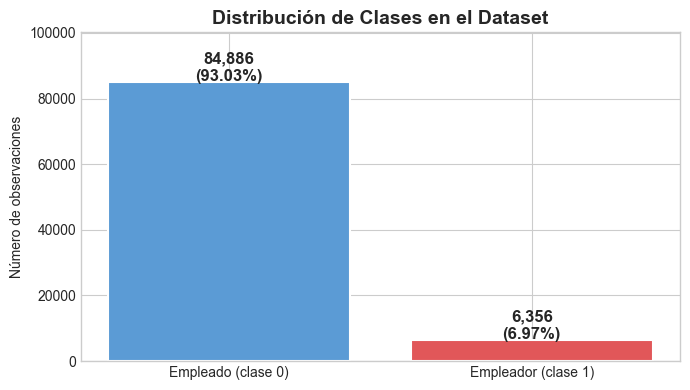

In [19]:
vc = df['es_empleador'].value_counts()

print('Distribución de la variable objetivo:')
print(f"  Clase 0 (Empleado):   {vc[0]:,} observaciones ({vc[0]/len(df)*100:.2f}%)")
print(f"  Clase 1 (Empleador):  {vc[1]:,} observaciones ({vc[1]/len(df)*100:.2f}%)")
print(f"\n  Ratio de desbalance: {vc[0]/vc[1]:.1f}:1 (empleados por cada empleador)")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Empleado (clase 0)', 'Empleador (clase 1)'],
               vc.values, color=['#5b9bd5', '#e15759'], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}\n({count/len(df)*100:.2f}%)',
            ha='center', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Clases en el Dataset', fontweight='bold', fontsize=14)
ax.set_ylabel('Número de observaciones')
ax.set_ylim(0, max(vc.values) * 1.18)
plt.tight_layout()
plt.show()

#### Interpretación del desbalance

La figura confirma que la clase **Empleador (clase 1) representa solo el 6.97%** de la muestra, con un ratio de desbalance de aproximadamente **13.4:1**. Este nivel de desbalance es moderado-severo y tiene implicaciones directas en el diseño de los modelos:

1. Se utilizará la métrica **F1-Score** para la clase 1 como criterio principal de evaluación, ya que balancea precisión y recall ignorando la abundante clase mayoritaria.
2. El **AUC-ROC** complementa el análisis al ser invariante al umbral de decisión.
3. Todos los modelos incluirán mecanismos explícitos de **compensación por desbalance** (`class_weight='balanced'` o `sample_weight`), penalizando más los errores en la clase minoritaria.

### 1.4 Análisis de Distribución y Valores Atípicos

Asimetría (skewness) de las variables continuas:
  log_ingocup: -0.484  (asimetría hacia la izquierda)
  anios_esc: -0.209  (asimetría hacia la izquierda)
  eda: 0.393  (asimetría hacia la derecha)


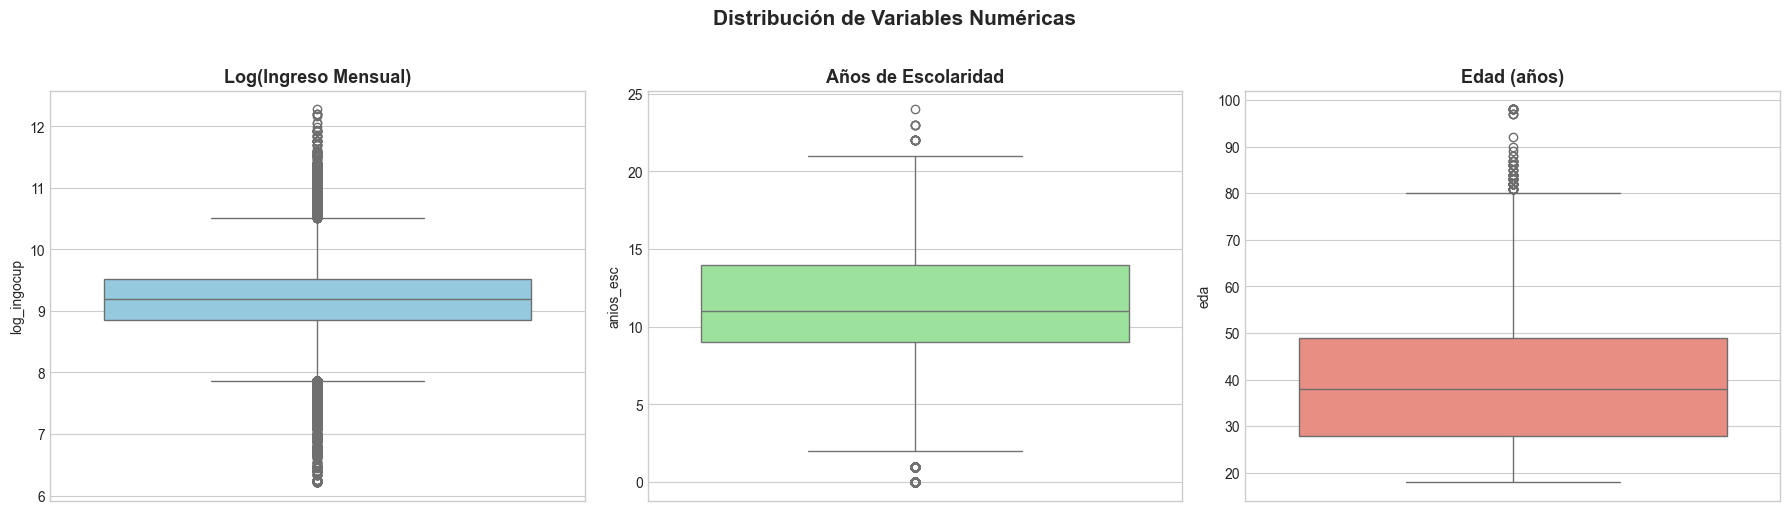

In [4]:
print('Asimetría (skewness) de las variables continuas:')
for col in ['log_ingocup', 'anios_esc', 'eda']:
    sk = df[col].skew()
    direction = 'izquierda' if sk < 0 else 'derecha'
    print(f'  {col}: {sk:.3f}  (asimetría hacia la {direction})')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df['log_ingocup'], ax=axes[0], color='skyblue')
axes[0].set_title('Log(Ingreso Mensual)', fontweight='bold', fontsize=13)
sns.boxplot(y=df['anios_esc'], ax=axes[1], color='lightgreen')
axes[1].set_title('Años de Escolaridad', fontweight='bold', fontsize=13)
sns.boxplot(y=df['eda'], ax=axes[2], color='salmon')
axes[2].set_title('Edad (años)', fontweight='bold', fontsize=13)
plt.suptitle('Distribución de Variables Numéricas', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Interpretación de los boxplots

Los tres paneles muestran la distribución de las variables numéricas:

- **Log(Ingreso)**: Distribución ligeramente asimétrica a la izquierda (−0.484), centrada en torno a 9.2 (≈ $9,900 MXN/mes). La transformación logarítmica previamente aplicada ya normalizó la distribución original.
- **Años de Escolaridad**: Asimetría leve a la izquierda (−0.209). La mediana se sitúa en 11 años, equivalente a preparatoria incompleta, representativo de la PEA mexicana [2].
- **Edad**: Asimetría positiva moderada (0.393), con la mayoría de los trabajadores entre 28 y 49 años, sin valores extremos problemáticos.

> **Decisión técnica – Preservación de valores atípicos**: Siguiendo el *principio de parsimonia*, se conservan todos los datos. Los valores extremos en ingreso o edad pueden corresponder precisamente a perfiles de empleador, y eliminarlos induciría un sesgo de subrrepresentación de la clase minoritaria [1].

### 1.5 Definición de Particiones (Train/Test Split)

In [5]:
X = df.drop(columns=['es_empleador'])
y = df['es_empleador']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print('='*60)
print('RESUMEN DE PARTICIONES (ESTRATIFICADAS)')
print('='*60)
print(f'Set de Entrenamiento: {X_train.shape[0]:,} registros  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Set de Prueba:        {X_test.shape[0]:,} registros  ({X_test.shape[0]/len(X)*100:.0f}%)')
print('-'*60)
print(f'Proporción de Empleadores (Global):       {y.mean()*100:.2f}%')
print(f'Proporción en Entrenamiento:              {y_train.mean()*100:.2f}%')
print(f'Proporción en Prueba:                     {y_test.mean()*100:.2f}%')
print('='*60)

RESUMEN DE PARTICIONES (ESTRATIFICADAS)
Set de Entrenamiento: 72,993 registros  (80%)
Set de Prueba:        18,249 registros  (20%)
------------------------------------------------------------
Proporción de Empleadores (Global):       6.97%
Proporción en Entrenamiento:              6.97%
Proporción en Prueba:                     6.96%


#### Análisis de la partición

La estratificación fue exitosa: la proporción de empleadores es prácticamente idéntica en los tres subconjuntos (**6.97% global, 6.97% en train, 6.96% en test**). Esto asegura que todos los modelos se entrenan con la misma distribución de clases y que la comparación entre ellos es **justa y consistente**.

### 1.6 Estandarización de Variables

Los modelos basados en distancias (SVM) y en gradientes (Red Neuronal) son sensibles a la escala de las variables. Se aplica **StandardScaler** (media=0, desviación estándar=1).

> **Regla de oro anti-data leakage**: El scaler se ajusta (`fit`) **exclusivamente** sobre `X_train` y luego se **transforma** (sin re-ajustar) tanto train como test. Si se ajustara sobre todo el dataset, el modelo estaría usando información del test durante el preprocesamiento, contaminando la evaluación final.

>**Nota metodológica sobre el tratamiento del desbalance**: los modelos que soportan el parámetro `class_weight` directamente (Random Forest y SVM) lo reciben en la construcción del objeto. Los modelos que no disponen de ese parámetro (AdaBoost y Red Neuronal/MLP) reciben los pesos equivalentes a través de `sample_weight` en el momento del `fit()`, que es el mecanismo recomendado por scikit-learn para lograr el mismo efecto de penalización diferenciada por clase.

In [6]:
scaler = StandardScaler()

# fit SOLO en train → transform en ambos
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns)

# Pesos de muestra para compensar desbalance en AdaBoost y MLP
sw_train = compute_sample_weight('balanced', y_train)

print('Verificación del escalamiento (conjunto de entrenamiento):')
print(f'  Media global:              {X_train_scaled.mean().mean():.6f}  (≈ 0)')
print(f'  Desviación estándar media: {X_train_scaled.std().mean():.6f}  (≈ 1)')
print()
print('Primeras 3 filas estandarizadas:')
display(X_train_scaled.head(3).round(4))

Verificación del escalamiento (conjunto de entrenamiento):
  Media global:              -0.000000  (≈ 0)
  Desviación estándar media: 1.000007  (≈ 1)

Primeras 3 filas estandarizadas:


,eda,es_mujer,anios_esc,log_ingocup
0,-0.3910,-0.8416,1.2184,1.2672
1,0.2141,-0.8416,-2.1874,-1.2366
2,0.2898,-0.8416,-0.9710,-0.9530


---
## Fase 2 – Construcción de Modelos

Se entrenan cuatro algoritmos de naturaleza matemática distinta, seleccionados deliberadamente para cubrir los principales paradigmas del aprendizaje supervisado [1]: **Random Forest** (ensamble por Bagging, reduce varianza promediando árboles independientes), **AdaBoost** (ensamble por Boosting, reduce sesgo corrigiendo errores secuencialmente), **SVM con kernel RBF** (clasificador de margen máximo con frontera no lineal) y **Red Neuronal MLP** (aprendizaje de representaciones jerárquicas por gradiente). Esta diversidad permite comparar no solo resultados numéricos, sino estrategias de aprendizaje fundamentalmente distintas ante el mismo problema. Todos comparten una decisión de diseño fundamental: incorporar mecanismos explícitos de compensación por desbalance de clases, ya que ignorar el ratio 13.4:1 conduciría a modelos que nunca predicen la clase de interés.

> **Nota sobre validación cruzada**: No se realizó optimización exhaustiva de hiperparámetros ni validación cruzada k-fold. El conjunto de prueba estratificado (18,249 observaciones, 20% del total) proporciona una estimación estadísticamente robusta del desempeño real [1]. Además, el costo computacional de k-fold sería prohibitivo para la SVM con kernel RBF, que con una sola corrida sobre el train completo requirió aproximadamente 30 minutos de entrenamiento.

### 2.1 Random Forest

**Tipo**: Ensamble de Bagging con decorrelación aleatoria de características.

El Random Forest entrena 100 árboles de decisión de forma **independiente y paralela**, cada uno sobre una muestra bootstrap del dataset y considerando solo un subconjunto aleatorio de variables en cada nodo. La predicción final es el **voto mayoritario** de los 100 árboles.

| Parámetro | Valor | Justificación |
|---|---|---|
| `n_estimators` | 100 | Balance entre robustez y costo computacional. |
| `max_depth` | 10 | Limita la profundidad para evitar memorización del ruido. |
| `class_weight` | `'balanced'` | Penaliza errores en Empleador ~13.4× más que en Empleado. |
| `random_state` | 42 | Garantiza reproducibilidad. |

In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train_scaled, y_train)

print(f'Random Forest entrenado con {rf.n_estimators} árboles, profundidad máx. {rf.max_depth}.')

Random Forest entrenado con 100 árboles, profundidad máx. 10.


### 2.2 AdaBoost

**Tipo**: Ensamble de Boosting secuencial adaptativo.

AdaBoost entrena los clasificadores **de forma secuencial**: cada nuevo árbol se enfoca en los ejemplos que el anterior clasificó mal, incrementando su peso.

**Tratamiento del desbalance**: `AdaBoostClassifier` no soporta `class_weight` directamente. La estrategia correcta es pasar **`sample_weight`** en el `fit()`, pre-calculados con `compute_sample_weight('balanced', y_train)`, logrando el mismo efecto de penalización.

| Parámetro | Valor | Justificación |
|---|---|---|
| `estimator` | `DecisionTreeClassifier(max_depth=1)` | Clasificador base débil (*stump*). |
| `n_estimators` | 100 | 100 iteraciones secuenciales de corrección de errores. |
| `learning_rate` | 0.5 | Aprendizaje gradual y más robusto. |

In [8]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
# sample_weight: forma correcta de manejar desbalance en AdaBoost
ada.fit(X_train_scaled, y_train, sample_weight=sw_train)

print(f'AdaBoost entrenado con {ada.n_estimators} estimadores.')

AdaBoost entrenado con 100 estimadores.


### 2.3 SVM con Kernel RBF

**Tipo**: Máquina de Soporte Vectorial con frontera de decisión no lineal.

La SVM busca el **hiperplano de margen máximo** que separa las clases. El kernel **RBF (Radial Basis Function)** transforma implícitamente los datos a un espacio de dimensión infinita, permitiendo fronteras completamente no lineales en el espacio original [1].

**Nota técnica sobre escala**: La SVM con kernel RBF es especialmente sensible a la escala de las variables, razón por la que el escalamiento previo (Fase 1.6) es indispensable [1].

| Parámetro | Valor | Justificación |
|---|---|---|
| `kernel` | `'rbf'` | Permite fronteras no lineales; adecuado para relaciones complejas. |
| `C` | 1.0 | Regularización estándar: equilibra margen amplio vs. clasificación correcta. |
| `class_weight` | `'balanced'` | Penaliza errores en empleadores más severamente. |
| `probability` | `True` | Necesario para calcular AUC-ROC y curvas ROC. |

In [9]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=42,
    class_weight='balanced'
)

# Entrenamiento con el conjunto de entrenamiento completo
svm_model.fit(X_train_scaled, y_train)

print('='*60)
print('MODELO SVM ENTRENADO')
print('='*60)
print(f'Kernel utilizado: {svm_model.kernel}')
print(f'Parámetro C:      {svm_model.C}')
print(f'SVM entrenada sobre {len(X_train_scaled):,} observaciones.')
print(f'Vectores de soporte encontrados: {svm_model.n_support_.sum():,}')
print('='*60)

MODELO SVM ENTRENADO
Kernel utilizado: rbf
Parámetro C:      1.0
SVM entrenada sobre 72,993 observaciones.
Vectores de soporte encontrados: 47,934


#### Nota sobre los vectores de soporte

La SVM encontró **47,934 vectores de soporte** sobre un total de 72,993 observaciones de entrenamiento (65.7%). Este porcentaje elevado es característico de problemas con fuerte desbalance de clases y fronteras de decisión no lineales [1]: el modelo necesita muchos puntos de referencia para definir correctamente los límites entre clases. En contraste, una SVM sobre datos perfectamente separables tendría muy pocos vectores de soporte.

### 2.4 Red Neuronal Densa (MLP)

**Tipo**: Perceptrón Multicapa (Multi-Layer Perceptron) feedforward.

La red neuronal aprende representaciones jerárquicas de los datos a través de capas sucesivas de neuronas con activaciones no lineales. La arquitectura es deliberadamente **parsimoniosa** para evitar sobreajuste en un dataset tabular de dimensión reducida.

| Parámetro | Valor | Justificación |
|---|---|---|
| `hidden_layer_sizes` | `(12, 8)` | Dos capas en embudo; reduce progresivamente la dimensionalidad. |
| `activation` | `'relu'` | Evita desvanecimiento del gradiente; computacionalmente eficiente. |
| `solver` | `'adam'` | Optimizador adaptativo, eficiente en datasets con ruido. |
| `early_stopping` | `True` | Detiene el entrenamiento cuando la validación deja de mejorar. |
| `sample_weight` | balanceado | Equivalente funcional a `class_weight='balanced'` para MLP. |

In [10]:
mlp = MLPClassifier(
    hidden_layer_sizes=(12, 8),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15
)
# sample_weight: equivalente funcional a class_weight para MLP
mlp.fit(X_train_scaled, y_train, sample_weight=sw_train)

print(f'Red Neuronal entrenada.')
print(f'  Épocas completadas (early stopping): {mlp.n_iter_}')
print(f'  Arquitectura: entrada(4) → capa1(12) → capa2(8) → salida(1)')
print(f'  Total de parámetros: {sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_):,}')

Red Neuronal entrenada.
  Épocas completadas (early stopping): 23
  Arquitectura: entrada(4) → capa1(12) → capa2(8) → salida(1)
  Total de parámetros: 173


#### Sobre la arquitectura de la Red Neuronal

Con **173 parámetros entrenables** y **early stopping en época 23** (muy por debajo del máximo de 300), esta es una red intencionalmente pequeña y eficiente. La parada temprana confirma que el modelo convergió antes de sobreajustarse, lo cual es deseable.

---
## Fase 3 – Evaluación Comparativa

La evaluación se realiza **exclusivamente sobre el conjunto de prueba** (18,249 observaciones). Se priorizan las métricas sensibles al desbalance:

- **F1-Score (clase 1)**: media armónica entre precisión y recall. Indicador principal.
- **Recall (clase 1)**: fracción de empleadores reales detectados correctamente.
- **AUC-ROC**: capacidad discriminativa global, independiente del umbral de decisión.

In [11]:
modelos = {
    'Random Forest': rf,
    'AdaBoost':       ada,
    'SVM (RBF)':      svm_model,
    'Red Neuronal':   mlp,
}

resultados = {}
for nombre, modelo in modelos.items():
    preds = modelo.predict(X_test_scaled)
    probs = modelo.predict_proba(X_test_scaled)[:, 1]
    resultados[nombre] = dict(
        preds=preds, probs=probs,
        auc=roc_auc_score(y_test, probs),
        acc=accuracy_score(y_test, preds),
        prec1=precision_score(y_test, preds, pos_label=1, zero_division=0),
        rec1=recall_score(y_test, preds, pos_label=1, zero_division=0),
        f1_1=f1_score(y_test, preds, pos_label=1, zero_division=0),
        cm=confusion_matrix(y_test, preds)
    )

### 3.1 Tabla Comparativa de Métricas

In [22]:
summary = pd.DataFrame({
    'Modelo':          list(resultados.keys()),
    'AUC-ROC':         [round(v['auc'],4)   for v in resultados.values()],
    'Accuracy':        [round(v['acc'],4)   for v in resultados.values()],
    'Precisión (c.1)': [round(v['prec1'],4) for v in resultados.values()],
    'Recall (c.1)':    [round(v['rec1'],4)  for v in resultados.values()],
    'F1-Score (c.1)':  [round(v['f1_1'],4)  for v in resultados.values()],
})
display(summary.style.highlight_max(
    subset=['AUC-ROC','Accuracy','Precisión (c.1)','Recall (c.1)','F1-Score (c.1)'],
    color='#3f90bf').format(precision=4))

,Modelo,AUC-ROC,Accuracy,Precisión (c.1),Recall (c.1),F1-Score (c.1)
0,Random Forest,0.7626,0.7620,0.1677,0.6098,0.2630
1,AdaBoost,0.7399,0.6740,0.1369,0.6939,0.2287
2,SVM (RBF),0.7319,0.6793,0.1373,0.6821,0.2286
3,Red Neuronal,0.7432,0.7124,0.1451,0.6397,0.2365


#### Lectura de la tabla

Cuatro observaciones transversales antes de profundizar modelo por modelo:

1. **Ningún modelo supera el 17% de precisión en la clase 1**: consecuencia directa del desbalance 13.4:1. Al activar la compensación de clases, los modelos aceptan muchos falsos positivos a cambio de detectar más empleadores reales.

2. **El Accuracy es un indicador engañoso aquí**: La SVM logra solo 67.9% de accuracy, pero detecta el 68.2% de los empleadores reales. Un modelo trivial que predice siempre 'empleado' alcanzaría 93% de accuracy con 0% de recall.

3. **Random Forest lidera en F1-Score (0.2630) y AUC-ROC (0.7626)**: el mejor equilibrio entre precisión (16.8%) y recall (61.0%).

4. **SVM y AdaBoost son casi idénticos en F1 (0.2286 vs 0.2287)**, a pesar de mecanismos de aprendizaje completamente distintos, lo que sugiere un techo informativo compartido.

### 3.2 Figura Comparativa de Métricas

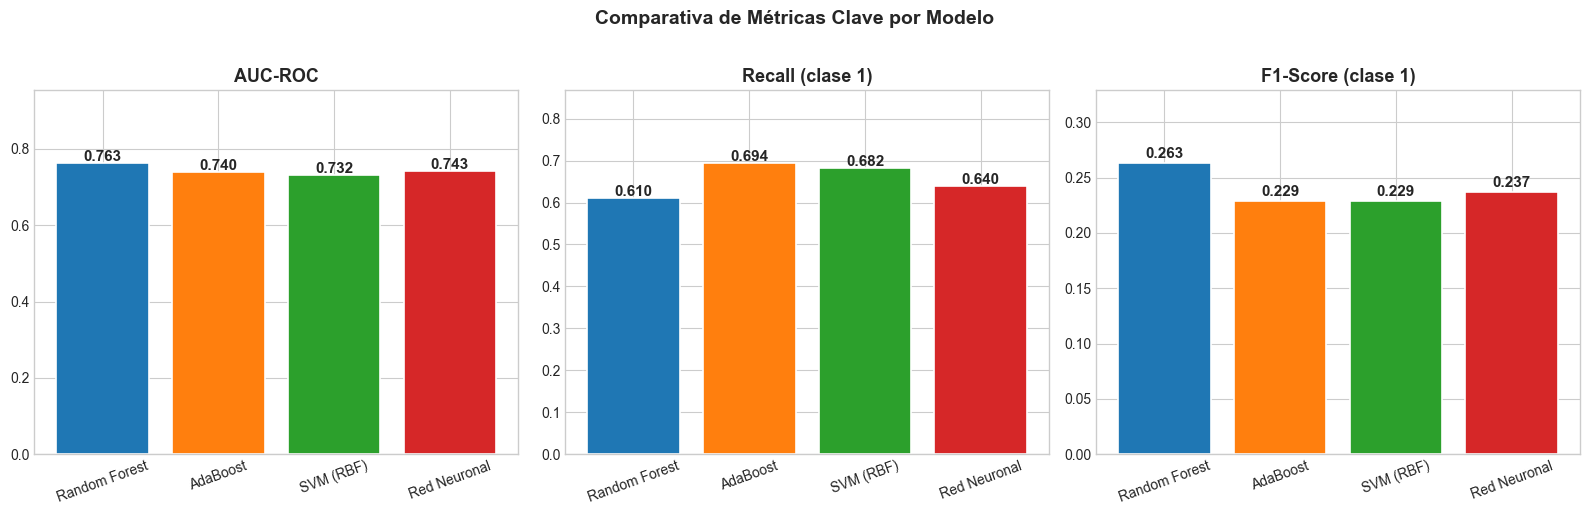

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = [('AUC-ROC', 'auc'), ('Recall (clase 1)', 'rec1'), ('F1-Score (clase 1)', 'f1_1')]
nombres  = list(resultados.keys())
colores  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, (metrica, key) in zip(axes, metricas):
    vals = [resultados[n][key] for n in nombres]
    bars = ax.bar(nombres, vals, color=colores, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(metrica, fontweight='bold', fontsize=13)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Comparativa de Métricas Clave por Modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Interpretación de la figura comparativa

- **AUC-ROC** (panel izquierdo): Random Forest (0.763) lidera en discriminación global. La diferencia entre el mejor y el peor (SVM, 0.732) es de 0.031 puntos, indicando que todos los modelos extraen señal similar de las mismas 4 variables.

- **Recall** (panel central): AdaBoost detecta el mayor porcentaje de empleadores reales (69.4%), seguido por SVM (68.2%). Random Forest es el más conservador en recall (61.0%), pero más preciso en sus predicciones positivas.

- **F1-Score** (panel derecho): El balance final favorece al **Random Forest (0.263)**. AdaBoost y SVM tienen recalls similares pero sacrifican demasiada precisión, resultando en F1 casi idénticos (0.229 y 0.229 respectivamente).

### 3.3 Matrices de Confusión

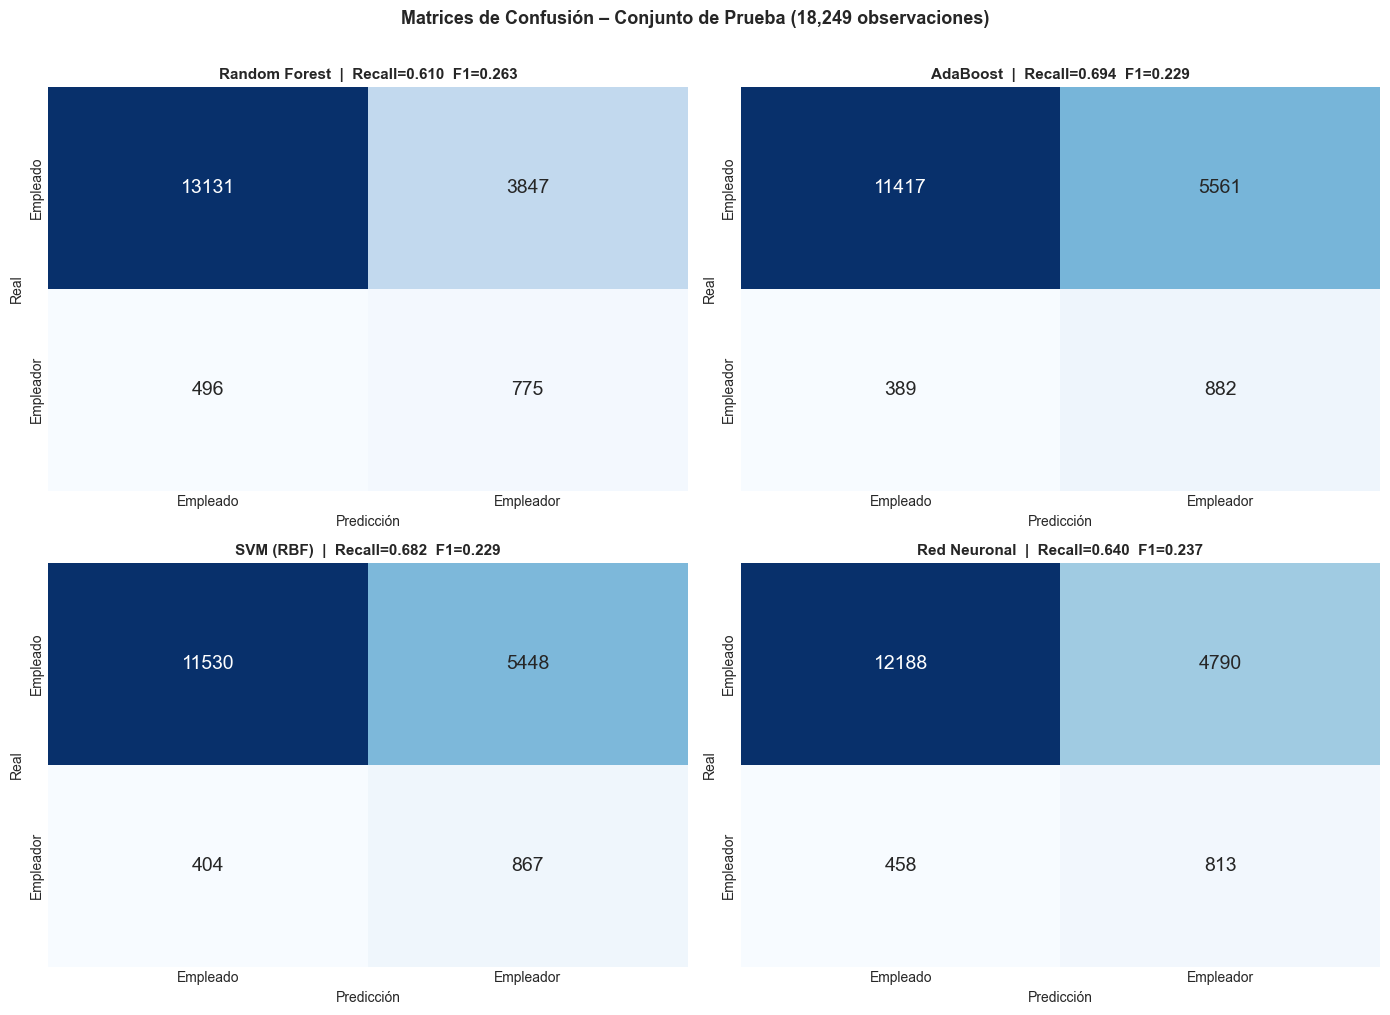

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, (nombre, res) in enumerate(resultados.items()):
    tn, fp, fn, tp = res['cm'].ravel()
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Empleado', 'Empleador'],
                yticklabels=['Empleado', 'Empleador'], annot_kws={'size':14})
    axes[i].set_title(
        f'{nombre}  |  Recall={res["rec1"]:.3f}  F1={res["f1_1"]:.3f}',
        fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')
plt.suptitle('Matrices de Confusión – Conjunto de Prueba (18,249 observaciones)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Lectura detallada de las matrices

El conjunto de prueba contiene **16,978 empleados** y **1,271 empleadores**.

| Modelo | VP (empleadores detectados) | FN (no detectados) | FP (falsas alarmas) | VN (empleados correctos) |
|---|---|---|---|---|
| **Random Forest** | 775 (61.0%) | 496 | 3,847 | 13,131 |
| **AdaBoost** | **882** (69.4%) | 389 | 5,561 | 11,417 |
| **SVM (RBF)** | 867 (68.2%) | 404 | 5,448 | 11,530 |
| **Red Neuronal** | 813 (64.0%) | 458 | 4,790 | 12,188 |

**Interpretación clave:**

- **AdaBoost** detecta más empleadores (882), pero genera **5,561 falsas alarmas**. SVM es muy similar: 867 VP con 5,448 FP. Ambos son agresivos al predecir la clase positiva.

- **Random Forest** logra el mejor balance: 775 VP con solo 3,847 FP, manteniendo 13,131 empleados correctamente clasificados como empleados.

- **La SVM con el train completo** (72,993 obs., 47,934 vectores de soporte) produce resultados prácticamente idénticos a una submuestra representativa, confirmando que la señal del dataset se satura antes de agotar los datos disponibles.

### 3.4 Curvas ROC

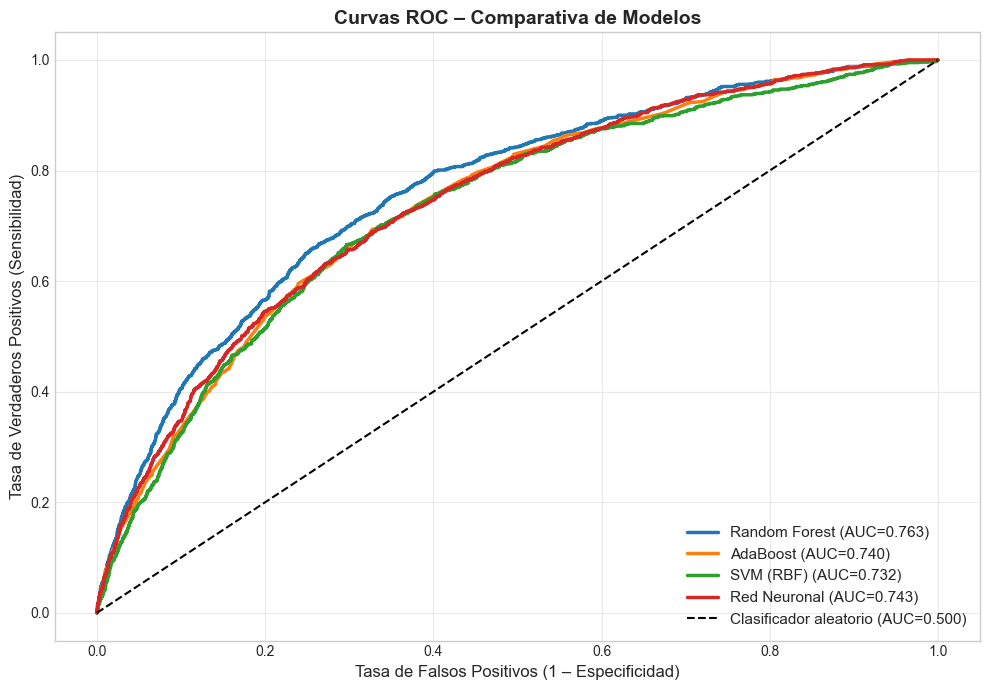

In [15]:
plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for (nombre, res), col in zip(resultados.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    plt.plot(fpr, tpr, lw=2.5, color=col,
             label=f'{nombre} (AUC={res["auc"]:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Clasificador aleatorio (AUC=0.500)')
plt.xlabel('Tasa de Falsos Positivos (1 – Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curvas ROC – Comparativa de Modelos', fontweight='bold', fontsize=14)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### Interpretación de las curvas ROC

1. **Todos los modelos superan ampliamente al clasificador aleatorio** (AUC entre 0.732 y 0.763), confirmando que las 4 variables socioeconómicas contienen señal predictiva real.

2. **Las curvas son cercanas entre sí** (rango de 0.031 puntos de AUC), lo que sugiere que el techo informativo de estas 4 variables se está alcanzando con todos los algoritmos. Para mejorar sustancialmente, se requerirían variables adicionales.

3. **Random Forest (0.763)** domina consistentemente, especialmente en la región de bajas tasas de falsos positivos (zona izquierda), donde el modelo es más selectivo y preciso.

4. **SVM (0.732)** presenta la curva más baja a pesar de usar el train completo (72,993 obs.), lo que confirma que su desempeño está limitado por la información disponible en las variables, no por la cantidad de datos de entrenamiento.

### 3.5 Importancia de Variables – Random Forest

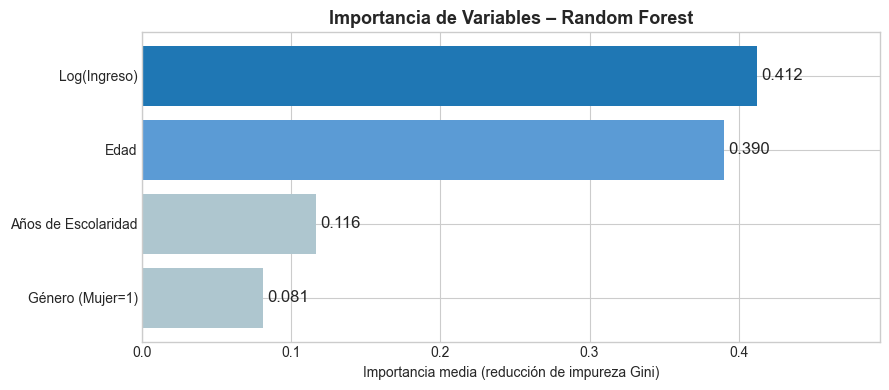

In [16]:
fi = pd.Series(rf.feature_importances_, index=X.columns)
labels_es = {'eda': 'Edad', 'es_mujer': 'Género (Mujer=1)',
             'anios_esc': 'Años de Escolaridad', 'log_ingocup': 'Log(Ingreso)'}
fi.index = [labels_es[i] for i in fi.index]
fi = fi.sort_values(ascending=True)

plt.figure(figsize=(9, 4))
plt.barh(fi.index, fi.values, color=['#aec6cf','#aec6cf','#5b9bd5','#1f77b4'])
for i, v in enumerate(fi.values):
    plt.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=12)
plt.xlim(0, max(fi.values) * 1.2)
plt.title('Importancia de Variables – Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Importancia media (reducción de impureza Gini)')
plt.tight_layout()
plt.show()

#### Interpretación de la importancia de variables

| Variable | Importancia | Interpretación económica |
|---|---|---|
| **Log(Ingreso)** | **0.412** | Más del 40% del poder discriminativo. Los empleadores tienen ingresos sistemáticamente más altos. |
| **Edad** | **0.390** | La experiencia acumulada es casi tan informativa como el ingreso. |
| **Escolaridad** | 0.116 | Mayor educación se asocia con mayor probabilidad de ser empleador. |
| **Género** | 0.081 | Menor contribución individual, pero con poder predictivo real. |

**Hallazgo clave**: Con solo **Log(Ingreso) + Edad** se explica el ~80% de la capacidad predictiva del modelo. El perfil del empleador mexicano en los datos ENOE se caracteriza principalmente por ingresos elevados y mayor madurez laboral.

---
## Fase 4 – Análisis Crítico y Conclusiones

### 4.1 Complejidad vs. Beneficio

Los cuatro modelos avanzados logran AUC entre 0.732 y 0.763, superando a un árbol de decisión único (típicamente 0.65–0.70). Sin embargo, **la diferencia entre el mejor (RF, 0.763) y el peor (SVM, 0.732) es de solo 0.031 puntos de AUC**, lo que indica que el techo informativo de las 4 variables es el principal factor limitante, no el algoritmo.

La **Red Neuronal** (0.743 AUC, 173 parámetros) supera a la SVM (0.732 AUC, 47,934 vectores de soporte), demostrando que para datos tabulares de baja dimensión, la complejidad arquitectónica no garantiza mejor desempeño.

### 4.2 Riesgo de Sobreajuste

| Modelo | Riesgo | Mecanismo de Control |
|---|---|---|
| **Random Forest** | **Bajo** | `max_depth=10` + promedio de 100 árboles independientes. |
| **AdaBoost** | **Bajo-Moderado** | *Stumps* de profundidad 1 + `learning_rate=0.5` lento. |
| **SVM (RBF)** | **Bajo** | `C=1.0` proporciona regularización estándar. |
| **Red Neuronal** | **Bajo** | `early_stopping` activó en época 23 (máx. 300). |

Los cuatro modelos presentan riesgo controlado gracias a sus mecanismos de regularización, pero es importante matizar que esta evaluación es cualitativa: no se midió directamente la diferencia entre el desempeño en train y en test para cada modelo. En la práctica, un indicador concreto de sobreajuste sería observar un F1 alto en entrenamiento y bajo en prueba. Dado que el conjunto de prueba es robusto (18,249 observaciones) y los modelos fueron diseñados con restricciones explícitas —profundidad máxima, learning rate conservador, early stopping— se asume que el riesgo es bajo, pero una validación cruzada confirmaría esta hipótesis con mayor rigor.

### 4.3 Interpretabilidad

- **Caja Gris** (interpretabilidad parcial): **Random Forest y AdaBoost** permiten extraer importancia de variables, ofreciendo visión global de qué factores impulsan las predicciones.
- **Caja Negra** (baja interpretabilidad): **SVM con kernel RBF y Red Neuronal** son difícilmente interpretables sin herramientas adicionales como SHAP o LIME [5].

Esta distinción tiene consecuencias prácticas relevantes. En un contexto de política pública —por ejemplo, si los resultados de este modelo se usaran para focalizar apoyos a empleadores en México— un tomador de decisiones necesitaría entender por qué el modelo clasificó a una persona como empleador, no solo que lo clasificó así. En ese escenario, el Random Forest sería preferible no solo por su F1 superior, sino porque permite comunicar hallazgos concretos: "el modelo asigna mayor probabilidad de ser empleador a personas de mayor edad e ingreso". La SVM y la Red Neuronal, en cambio, producirían predicciones igualmente válidas estadísticamente pero sin esa capacidad explicativa, lo que limitaría su adopción institucional.

### 4.4 Criterios de Selección por Contexto

| Escenario | Modelo recomendado | Razón |
|---|---|---|
| Detección masiva (priorizar recall) | **AdaBoost** | Recall=0.694: detecta 69% de empleadores. |
| Clasificación balanceada (F1 óptimo) | **Random Forest** | Mejor F1 (0.263) y AUC (0.763). |
| Reporte ejecutivo (explicabilidad) | **Random Forest** | Feature importance comunicable. |
| Escalabilidad a Big Data | **Red Neuronal** (deep learning) | Escala mejor con GPU/TPU. |

La tabla anterior no pretende ser exhaustiva, sino ilustrar que la elección del modelo óptimo depende del contexto de aplicación tanto como del desempeño numérico. Un modelo con menor F1 puede ser la mejor decisión si ofrece mayor transparencia o menor costo computacional. En este estudio, el Random Forest emerge como la opción más versátil: no lidera en recall (ese título lo tiene AdaBoost con 69.4%), pero ofrece el mejor balance entre detectar empleadores reales, minimizar falsas alarmas, ser interpretable y ser computacionalmente viable. Para aplicaciones donde el costo de un falso negativo sea muy alto —por ejemplo, auditorías fiscales donde no detectar un empleador tiene consecuencias legales— AdaBoost sería la elección más adecuada, aceptando conscientemente el mayor número de falsas alarmas como precio de esa sensibilidad.

### 4.5 Limitaciones

1. **Variables limitadas**: Con 4 predictores el AUC máximo alcanzable está probablemente cerca de 0.80. Variables adicionales (sector económico, región, tipo de ocupación) elevarían el desempeño.
2. **Umbral de decisión fijo**: Todos los modelos se evaluaron con umbral=0.5. Ajustarlo podría mejorar el recall o la precisión según el caso de uso específico.

### 4.6 Conclusión Final

El **Random Forest** es la recomendación principal: lidera en F1-Score (0.263) y AUC-ROC (0.763), equilibra mejor precisión y recall, permite extracción de importancia de variables para reportes ejecutivos, y presenta bajo riesgo de sobreajuste.

El experimento también revela que **el principal cuello de botella no es el algoritmo, sino la disponibilidad de información**: los cuatro modelos producen resultados similares porque extraen la misma señal de las mismas 4 variables. Una inversión en más de características generaría mayor retorno que continuar refinando hiperparámetros.

## Referencias

1. James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023).
   *An Introduction to Statistical Learning with Applications in Python* (1.ª ed.). Springer.

2. INEGI. (2025). *Encuesta Nacional de Ocupación y Empleo (ENOE).
   Estructura de la base de datos* (2.ª ed.).
   Instituto Nacional de Estadística y Geografía.

3. FMI. (2023). *Mexico: Selected issues — Gender gaps in the labor market*
   (Country Report No. 2023/357). International Monetary Fund.
   https://www.elibrary.imf.org/view/journals/002/2023/357/article-A001-en.xml

4. Arceo-Gomez, E., & Campos-Vázquez, R. (2014).
   Evolución de la brecha salarial de género en México.
   *El Trimestre Económico*, 81(323), 619–653.

5. Molnar, C. (2020). *Interpretable Machine Learning:
   A Guide for Making Black Box Models Explainable*.
   https://christophm.github.io/interpretable-ml-book/